# Homework 4

The author acknowledges the use of Claude in the preparation or completion of this assignment. Claude was used in the following way(s) in this assignment: assisting with creating architecture plan, front end code, backend skeleton code, and general debugging.

In [104]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display, Markdown
import requests
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
from sportsdataverse import load_cfb_pbp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss
from scipy.stats import pearsonr
from supabase import create_client

In [ ]:
seasons = range(2021, 2026)
games_list = []

# load season data
for season in seasons:
    url = f"https://raw.githubusercontent.com/sportsdataverse/cfbfastR-data/main/schedules/csv/cfb_schedules_{season}.csv"
    df_season = pd.read_csv(url)
    games_list.append(df_season)

raw_games = pd.concat(games_list, ignore_index=True)

# clean and filter for completed games with valid scores
games_clean = raw_games[
    (raw_games['completed'] == True) &
    (raw_games['home_points'].notna()) &
    (raw_games['away_division']=='fbs') &
    (raw_games['away_points'].notna()) &
    (raw_games['season_type'].isin(['regular']))
][['season', 'week', 'home_team', 'away_team', 'home_points', 'away_points']].sort_values(['season', 'week']).reset_index(drop=True)

In [107]:
# load the play by play data
seasons = list(range(2021, 2026))
pbp_raw = load_cfb_pbp(seasons, return_as_pandas=True)

pbp_cfb = pbp_raw[
    (pbp_raw['seasonType'] == 2) &
    (pbp_raw['start.TimeSecsRem'].notna()) &
    (pbp_raw['homeScore'].notna()) &
    (pbp_raw['awayScore'].notna()) &
    (pbp_raw['homeTeamName'].notna()) &
    (pbp_raw['awayTeamName'].notna())
][['season', 'game_id', 'homeTeamName', 'awayTeamName', 'start.TimeSecsRem', 'homeScore', 'awayScore']].copy()

# renaming to match game naming
pbp_cfb = pbp_cfb.rename(columns={
    'homeTeamName': 'home_team',
    'awayTeamName': 'away_team',
    'start.TimeSecsRem': 'game_seconds_remaining',
    'homeScore': 'home_score',
    'awayScore': 'away_score'
})

pbp_cfb = pbp_cfb.sort_values(['season', 'game_id', 'game_seconds_remaining'], ascending=[True, True, False])

pbp_cfb['home_lead'] = pbp_cfb['home_score'] - pbp_cfb['away_score']

prev_seconds = pbp_cfb.groupby('game_id')['game_seconds_remaining'].shift(1).fillna(3600)
pbp_cfb['play_duration'] = (prev_seconds - pbp_cfb['game_seconds_remaining']).clip(lower=0)

In [ ]:
load_dotenv()
CFBD_API_KEY = os.getenv("CFBD_API_KEY")
headers = {"Authorization": f"Bearer {CFBD_API_KEY}"}

# pulling win probability from CFBD API
seasons = range(2021, 2026)
wp_list = []

for yr in seasons:
    url = f"https://api.collegefootballdata.com/metrics/wp/pregame?year={yr}&seasonType=regular"
    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code == 200:
            for game in response.json():
                wp_list.append({
                    'season': game.get('season'),
                    'week':   game.get('week'),
                    'game_id': game.get('gameId'),
                    'home_team': game.get('homeTeam'),
                    'away_team': game.get('awayTeam'),
                    'home_wp': game.get('homeWinProbability'),
                })
    except Exception:
        continue

# dropping any rows with missing win probability
wp_df = pd.DataFrame(wp_list).dropna(subset=['home_wp']).reset_index(drop=True)

# converting win probability to float
wp_df['home_wp'] = wp_df['home_wp'].astype(float)

## Part 1
### SRS model of score differential and home/away
Be sure to have an effect for the home team in each model.  Give the top 10 and botton 10 teams for each season from 2021 to 2025.

In [ ]:
# calculate SRS
def calc_srs_scratch(df):
    # resets row index to start at 0
    df = df.reset_index(drop=True)
    # gets first value of season (index 0)
    season = df['season'].iloc[0]

    # get every unique team name by combining home and away teams
    teams = np.unique(np.concatenate([df['home_team'].unique(), df['away_team'].unique()]))
    n_games = len(df)

    # creates matrix of all zeros, ngames x nteams
    X = pd.DataFrame(0.0, index=range(n_games), columns=teams)

    # fill in matrix with home (1) and away team (0)
    for i, row in df.iterrows():
        X.loc[i, row['home_team']] = 1.0
        X.loc[i, row['away_team']] = -1.0

    # score differential
    margin = df['home_points'] - df['away_points']
    X = sm.add_constant(X)
    fit = sm.OLS(margin, X).fit()
    srs_vec = fit.params.fillna(0)
    srs_centered = srs_vec - srs_vec.mean()

    # returns a dataframe with the SRS values for each team for each season
    return pd.DataFrame({
        'team': srs_centered.index,
        'season': season,
        'SRS': np.round(srs_centered.values, 2)
    })

In [ ]:
# creates a list to store SRS ratings for each season
srs_ratings_list = []
for yr, season_df in games_clean.groupby('season'):
    srs_ratings_list.append(calc_srs_scratch(season_df))

srs_by_season = pd.concat(srs_ratings_list, ignore_index=True)

In [ ]:
# for each year/season
for yr in sorted(srs_by_season['season'].unique()):
    # get the data for the current season and sort descending by SRS
    season = srs_by_season[
        (srs_by_season['season'] == yr) & (srs_by_season['team'] != '(Intercept)')
    ].sort_values('SRS', ascending=False).reset_index(drop=True)

    # top 10 teams per season
    top = season.head(10).copy()
    top['Rank'] = top.index + 1
    top = top[['Rank', 'team', 'SRS']].rename(columns={'team': 'Team'})

    # bottom 10 teams per season
    bottom = season.tail(10).sort_values('SRS').reset_index(drop=True)
    bottom['Rank'] = range(len(season) - 9, len(season) + 1)
    bottom = bottom[['Rank', 'team', 'SRS']].rename(columns={'team': 'Team'})

    display(Markdown(f"### Season: {yr}"))
    display(Markdown("**Top 10**"))
    display(Markdown(top.to_markdown(index=False)))
    display(Markdown("**Bottom 10**"))
    display(Markdown(bottom.to_markdown(index=False)))

### Season: 2021

**Top 10**

|   Rank | Team           |   SRS |
|-------:|:---------------|------:|
|      1 | Georgia        | 35.58 |
|      2 | Alabama        | 29.23 |
|      3 | Ohio State     | 28.62 |
|      4 | Michigan       | 25.77 |
|      5 | Notre Dame     | 21.67 |
|      6 | Oklahoma State | 19.92 |
|      7 | Utah           | 19.82 |
|      8 | Cincinnati     | 19.35 |
|      9 | Iowa State     | 17.16 |
|     10 | Wisconsin      | 16.57 |

**Bottom 10**

|   Rank | Team                  |    SRS |
|-------:|:----------------------|-------:|
|    123 | Florida International | -33.09 |
|    124 | Jacksonville State    | -32.51 |
|    125 | Massachusetts         | -30.72 |
|    126 | Akron                 | -29.86 |
|    127 | Temple                | -28.79 |
|    128 | UConn                 | -28.02 |
|    129 | Southern Miss         | -22.21 |
|    130 | New Mexico State      | -21.6  |
|    131 | Arkansas State        | -21.33 |
|    132 | Duke                  | -20.71 |

...

### Season: 2025

**Top 10**

|   Rank | Team       |   SRS |
|-------:|:-----------|------:|
|      1 | Indiana    | 37.28 |
|      2 | Ohio State | 32.5  |
|      3 | Texas Tech | 31.9  |
|      4 | Oregon     | 30.13 |
|      5 | Notre Dame | 29.44 |
|      6 | Utah       | 25.56 |
|      7 | Miami      | 24.63 |
|      8 | Georgia    | 22.46 |
|      9 | USC        | 21.54 |
|     10 | Iowa       | 21.02 |

**Bottom 10**

|   Rank | Team          |    SRS |
|-------:|:--------------|-------:|
|    128 | Massachusetts | -37.85 |
|    129 | Sam Houston   | -28.88 |
|    130 | UL Monroe     | -25.6  |
|    131 | Charlotte     | -24.65 |
|    132 | Georgia State | -23.24 |
|    133 | Akron         | -22.99 |
|    134 | Ball State    | -22.58 |
|    135 | UTEP          | -20.7  |
|    136 | Kent State    | -20.29 |
|    137 | Rice          | -19.27 |

### Oponent Adjusted Game Control Model

In [ ]:
# captures how dominant team is through the game
# time-weighted average score differential for the hometeam across the game
def calc_game_gc(group):
    total_time = group['play_duration'].sum()
    denom = total_time if total_time > 0 else 1.0
    return pd.Series({'home_gc': (group['home_lead'] * group['play_duration']).sum() / denom})

# apply to each game, groups by game so each group is one game's worth of plays
gc_by_game = pbp_cfb.groupby(
    ['season', 'game_id', 'home_team', 'away_team'], group_keys=False
).apply(calc_game_gc).reset_index()

In [ ]:
# calculate adjusted game control
def calc_adj_gc_scratch(df):
    df = df.reset_index(drop=True)
    teams = np.unique(np.concatenate([df['home_team'].unique(), df['away_team'].unique()]))
    n_games = len(df)
    season = df['season'].iloc[0]

    # creating matrix of all zeros, ngames x nteams
    X = pd.DataFrame(0.0, index=range(n_games), columns=teams)
    for i, (_, row) in enumerate(df.iterrows()):
        X.loc[i, row['home_team']] = 1.0
        X.loc[i, row['away_team']] = -1.0

    # intercept to capture home field advantage
    X_design = sm.add_constant(X)

    # OLS adjusts for team strength
    fit = sm.OLS(df['home_gc'].values, X_design).fit()

    # center so that ratings are relative to the average team (0 = average)
    params = fit.params.fillna(0).rename(index={'const': '(Intercept)'})
    params_centered = params - params.mean()

    return pd.DataFrame({
        'team': params_centered.index,
        'season': season,
        'Adj_GC': np.round(params_centered.values, 2)
    })

In [ ]:
# loops through each season, collect adjusted game control values, and group into one dataframe
adj_gc_list = []
for yr, season_df in gc_by_game.groupby('season'):
    adj_gc_list.append(calc_adj_gc_scratch(season_df))

adj_gc_by_season = pd.concat(adj_gc_list, ignore_index=True)

In [ ]:
# show top 10 and bottom 10 teams per season
for yr in sorted(adj_gc_by_season['season'].unique()):
    season = adj_gc_by_season[
        (adj_gc_by_season['season'] == yr) & (adj_gc_by_season['team'] != '(Intercept)')
    ].sort_values('Adj_GC', ascending=False).reset_index(drop=True)

    top = season.head(10).copy()
    top['Rank'] = top.index + 1
    top = top[['Rank', 'team', 'Adj_GC']].rename(columns={'team': 'Team'})

    bottom = season.tail(10).sort_values('Adj_GC').reset_index(drop=True)
    bottom['Rank'] = range(len(season) - 9, len(season) + 1)
    bottom = bottom[['Rank', 'team', 'Adj_GC']].rename(columns={'team': 'Team'})

    display(Markdown(f"### Season: {yr}"))
    display(Markdown("**Top 10**"))
    display(Markdown(top.to_markdown(index=False)))
    display(Markdown("**Bottom 10**"))
    display(Markdown(bottom.to_markdown(index=False)))

### Season: 2021

**Top 10**

|   Rank | Team       |   Adj_GC |
|-------:|:-----------|---------:|
|      1 | Georgia    |    14.86 |
|      2 | Alabama    |    14.48 |
|      3 | Tennessee  |    12.1  |
|      4 | Ohio State |    11.51 |
|      5 | Michigan   |    10.31 |
|      6 | Wisconsin  |    10.01 |
|      7 | Ole Miss   |    10    |
|      8 | Samford    |     9.51 |
|      9 | Utah       |     9.42 |
|     10 | Cincinnati |     9.17 |

**Bottom 10**

|   Rank | Team                     |   Adj_GC |
|-------:|:-------------------------|---------:|
|    204 | Long Island University   |   -32.35 |
|    205 | Southeast Missouri State |   -28.54 |
|    206 | Eastern Illinois         |   -23.25 |
|    207 | Abilene Christian        |   -21.58 |
|    208 | Texas Southern           |   -16.67 |
|    209 | Yale                     |   -15.35 |
|    210 | Austin Peay              |   -15.2  |
|    211 | South Carolina State     |   -14.2  |
|    212 | Tennessee Tech           |   -14.05 |
|    213 | VMI                      |   -13.91 |

...

### Season: 2025

**Top 10**

|   Rank | Team       |   Adj_GC |
|-------:|:-----------|---------:|
|      1 | Indiana    |    16.82 |
|      2 | Notre Dame |    15.82 |
|      3 | Texas Tech |    13.28 |
|      4 | Oregon     |    13.2  |
|      5 | Alabama    |    12.78 |
|      6 | Ohio State |    12.64 |
|      7 | Iowa       |    12.19 |
|      8 | Oklahoma   |    12.01 |
|      9 | Georgia    |    10.89 |
|     10 | Ole Miss   |    10.85 |

**Bottom 10**

|   Rank | Team                 |   Adj_GC |
|-------:|:---------------------|---------:|
|    227 | Tennessee State      |   -38.24 |
|    228 | North Carolina A&T   |   -33.65 |
|    229 | East Tennessee State |   -26.32 |
|    230 | Houston Christian    |   -23.9  |
|    231 | Grambling            |   -20.35 |
|    232 | Central Connecticut  |   -18.2  |
|    233 | Chattanooga          |   -17.21 |
|    234 | Eastern Kentucky     |   -15.91 |
|    235 | Colgate              |   -14.89 |
|    236 | Northwestern State   |   -14.75 |

### Opponent Adjusted Average Win Probability

In [ ]:
# calculate adjusted win probability for each team
def calc_adj_awp_scratch(df):
    df = df.reset_index(drop=True)
    teams = np.unique(np.concatenate([df['home_team'].unique(), df['away_team'].unique()]))
    n_games = len(df)
    season = df['season'].iloc[0]

    X = pd.DataFrame(0.0, index=range(n_games), columns=teams)
    for i, (_, row) in enumerate(df.iterrows()):
        X.loc[i, row['home_team']] = 1.0
        X.loc[i, row['away_team']] = -1.0

    X_design = sm.add_constant(X)
    fit = sm.OLS(df['home_wp'].values, X_design).fit()
    
    params = fit.params.fillna(0).rename(index={'const': '(Intercept)'})
    params_centered = params - params.mean()

    return pd.DataFrame({
        'team': params_centered.index,
        'season': season,
        'Adj_AWP': np.round(params_centered.values, 4)
    })

In [88]:
awp_ratings_list = []
for yr, season_df in wp_df.groupby('season'):
    awp_ratings_list.append(calc_adj_awp_scratch(season_df))

awp_by_season = pd.concat(awp_ratings_list, ignore_index=True)

In [ ]:
# show top 10 and bottom 10 teams per season
for yr in sorted(awp_by_season['season'].unique()):
    season = awp_by_season[
        (awp_by_season['season'] == yr) & (awp_by_season['team'] != '(Intercept)')
    ].sort_values('Adj_AWP', ascending=False).reset_index(drop=True)

    top = season.head(10).copy()
    top['Rank'] = top.index + 1
    top = top[['Rank', 'team', 'Adj_AWP']].rename(columns={'team': 'Team'})

    bottom = season.tail(10).sort_values('Adj_AWP').reset_index(drop=True)
    bottom['Rank'] = range(len(season) - 9, len(season) + 1)
    bottom = bottom[['Rank', 'team', 'Adj_AWP']].rename(columns={'team': 'Team'})

    display(Markdown(f"### Season: {yr}"))
    display(Markdown("**Top 10**"))
    display(Markdown(top.to_markdown(index=False)))
    display(Markdown("**Bottom 10**"))
    display(Markdown(bottom.to_markdown(index=False)))

### Season: 2021

**Top 10**

|   Rank | Team       |   Adj_AWP |
|-------:|:-----------|----------:|
|      1 | Alabama    |    0.6236 |
|      2 | Ohio State |    0.6225 |
|      3 | Georgia    |    0.6124 |
|      4 | Oklahoma   |    0.5028 |
|      5 | Michigan   |    0.4979 |
|      6 | Cincinnati |    0.4875 |
|      7 | Wisconsin  |    0.4827 |
|      8 | Iowa State |    0.4633 |
|      9 | Notre Dame |    0.4479 |
|     10 | Utah       |    0.4468 |

**Bottom 10**

|   Rank | Team                 |   Adj_AWP |
|-------:|:---------------------|----------:|
|    215 | Bryant               |   -0.5697 |
|    216 | Houston Christian    |   -0.5456 |
|    217 | Hampton              |   -0.5339 |
|    218 | Wagner               |   -0.5274 |
|    219 | East Tennessee State |   -0.502  |
|    220 | Northwestern State   |   -0.4762 |
|    221 | Florida A&M          |   -0.4648 |
|    222 | Northern Arizona     |   -0.4548 |
|    223 | Saint Francis        |   -0.4487 |
|    224 | Central Arkansas     |   -0.4426 |

...

### Season: 2025

**Top 10**

|   Rank | Team       |   Adj_AWP |
|-------:|:-----------|----------:|
|      1 | Ohio State |    0.6519 |
|      2 | Notre Dame |    0.6102 |
|      3 | Indiana    |    0.6003 |
|      4 | Oregon     |    0.5839 |
|      5 | Miami      |    0.549  |
|      6 | Alabama    |    0.5442 |
|      7 | Utah       |    0.5256 |
|      8 | Texas Tech |    0.5246 |
|      9 | Georgia    |    0.514  |
|     10 | Texas A&M  |    0.5074 |

**Bottom 10**

|   Rank | Team              |   Adj_AWP |
|-------:|:------------------|----------:|
|    219 | Bryant            |   -0.5828 |
|    220 | Murray State      |   -0.578  |
|    221 | Prairie View A&M  |   -0.5669 |
|    222 | Alabama State     |   -0.5364 |
|    223 | Delaware State    |   -0.514  |
|    224 | Northern Colorado |   -0.5134 |
|    225 | Saint Francis     |   -0.511  |
|    226 | Florida A&M       |   -0.4938 |
|    227 | Howard            |   -0.4797 |
|    228 | Bucknell          |   -0.444  |

### Comparison

In [ ]:
# create one DataFrame with all ratings and teams
srs = srs_by_season[['team', 'season', 'SRS']].copy()
adj_awp = awp_by_season[awp_by_season['team'] != '(Intercept)'][['team', 'season', 'Adj_AWP']].copy()
adj_gc  = adj_gc_by_season[adj_gc_by_season['team'] != '(Intercept)'][['team', 'season', 'Adj_GC']].copy()

all_ratings = srs.merge(adj_awp, on=['team', 'season'], how='inner') \
                 .merge(adj_gc,  on=['team', 'season'], how='inner')

print(all_ratings.shape)
all_ratings.head()

(662, 5)


,team,season,SRS,Adj_AWP,Adj_GC
0,Air Force,2021,9.39,0.2288,9.07
1,Akron,2021,-29.86,-0.2816,-3.76
2,Alabama,2021,29.23,0.6236,14.48
3,Arizona,2021,-7.70,-0.0338,1.92
4,Arizona State,2021,10.87,0.3972,4.55


## Part 2
### Assess which of the models has the best predictive out of sample performance by splitting each season into train and test sets. Explain why your choice of splits is appropriate

In [ ]:
# using logistic regression to model the probability of the prediction of being correct
def eval_predictive(games_df, rating_df, rating_col, label):
    results = []
    for yr in sorted(games_df['season'].unique()):
        season_games = games_df[games_df['season'] == yr].copy()

        train = season_games[season_games['week'] <= 7]
        test  = season_games[season_games['week'] > 7]

        # build train ratings from train games only
        train_ratings = rating_df[rating_df['season'] == yr].set_index('team')[rating_col]

        def get_diff(row):
            h = train_ratings.get(row['home_team'], 0)
            a = train_ratings.get(row['away_team'], 0)
            return h - a

        test = test.copy()
        test['rating_diff'] = test.apply(get_diff, axis=1)
        test['home_win'] = (test['home_points'] > test['away_points']).astype(int)
        test = test.dropna(subset=['rating_diff'])

        if len(test) < 10:
            continue

        # fit logistic on train diff predicting win
        train2 = train.copy()
        train2['rating_diff'] = train2.apply(get_diff, axis=1)
        train2['home_win'] = (train2['home_points'] > train2['away_points']).astype(int)
        train2 = train2.dropna(subset=['rating_diff'])

        lr = LogisticRegression()
        lr.fit(train2[['rating_diff']], train2['home_win'])

        probs = lr.predict_proba(test[['rating_diff']])[:, 1]

        results.append({
            'season': yr,
            'model': label,
            'brier': brier_score_loss(test['home_win'], probs),
            'log_loss': log_loss(test['home_win'], probs),
            'n_games': len(test)
        })

    return pd.DataFrame(results)

# run for all three models
perf_srs = eval_predictive(games_clean, srs, 'SRS', 'SRS')
perf_awp = eval_predictive(games_clean, adj_awp, 'Adj_AWP', 'Adj AWP')
perf_gc  = eval_predictive(games_clean, adj_gc, 'Adj_GC', 'Adj GC')

perf_all = pd.concat([perf_srs, perf_awp, perf_gc], ignore_index=True)

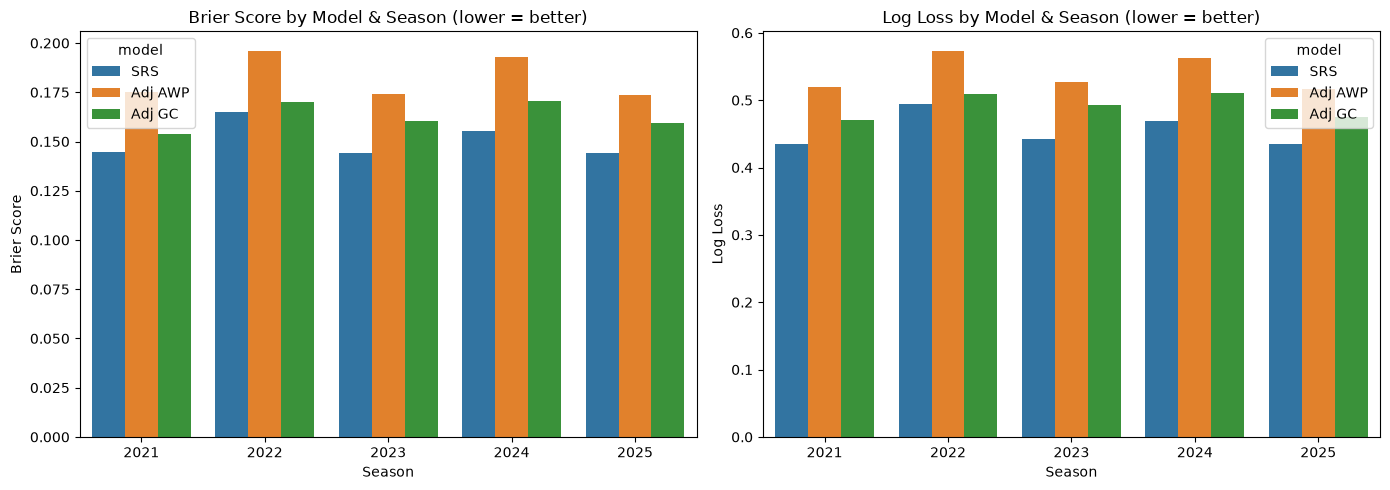

          brier  log_loss
model                    
Adj AWP  0.1823    0.5396
Adj GC   0.1628    0.4912
SRS      0.1506    0.4553


In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=perf_all, x='season', y='brier', hue='model', ax=axes[0], palette='tab10')
axes[0].set_title('Brier Score by Model & Season (lower = better)')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Brier Score')

sns.barplot(data=perf_all, x='season', y='log_loss', hue='model', ax=axes[1], palette='tab10')
axes[1].set_title('Log Loss by Model & Season (lower = better)')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Log Loss')

plt.tight_layout()
plt.show()

print(perf_all.groupby('model')[['brier','log_loss']].mean().round(4))

## Part 3
### Assess which of the models has the best repeatability by splitting each season into train and test sets. Explain why your choice of splits is appropriate 

In [123]:
def eval_repeatability(games_df, rating_fn, rating_col, label):
    results = []
    for yr in sorted(games_df['season'].unique()):
        season_games = games_df[games_df['season'] == yr].copy()
        mid = 7

        first_half  = season_games[season_games['week'] <= mid]
        second_half = season_games[season_games['week'] > mid]

        # compute ratings for each half
        r1 = rating_fn(first_half).set_index('team')[rating_col]
        r2 = rating_fn(second_half).set_index('team')[rating_col]

        # only correlate with teams that appear in both halves
        common = r1.index.intersection(r2.index)

        # calculate correlation with r
        corr, _ = pearsonr(r1[common], r2[common])
        results.append({'season': yr, 'model': label, 'correlation': round(corr, 3)})

    return pd.DataFrame(results)

# correlate AWP ratings 
def eval_repeatability_awp(wp_df, label):
    results = []
    for yr in sorted(wp_df['season'].unique()):
        season_wp = wp_df[wp_df['season'] == yr].copy()
        mid = 7

        first_half  = season_wp[season_wp['week'] <= mid]
        second_half = season_wp[season_wp['week'] > mid]

        r1 = calc_adj_awp_scratch(first_half).set_index('team')['Adj_AWP']
        r2 = calc_adj_awp_scratch(second_half).set_index('team')['Adj_AWP']

        common = r1.index.intersection(r2.index)
        
        corr, _ = pearsonr(r1[common], r2[common])
        results.append({'season': yr, 'model': label, 'correlation': round(corr, 3)})

    return pd.DataFrame(results)

rep_awp = eval_repeatability_awp(wp_df, 'Adj AWP')

# wrappers prevent having to create separate functions
# wrap each rating function to match expected signature
def srs_fn(df):
    return calc_srs_scratch(df).rename(columns={'SRS': 'SRS'})

def awp_fn(df):
    # use pre-game wp merged with games — need wp_df filtered to same games
    game_ids = df['game_id'].unique() if 'game_id' in df.columns else []
    sub = wp_df[wp_df['game_id'].isin(game_ids)] if len(game_ids) else wp_df[wp_df['season'] == df['season'].iloc[0]]
    return calc_adj_awp_scratch(sub).rename(columns={'Adj_AWP': 'Adj_AWP'})

def gc_fn(df):
    # df here is gc_by_game filtered to a season half
    return calc_adj_gc_scratch(df).rename(columns={'Adj_GC': 'Adj_GC'})

rep_srs = eval_repeatability(games_clean, srs_fn, 'SRS', 'SRS')

def eval_repeatability_gc(gc_df, label):
    results = []
    for yr in sorted(gc_df['season'].unique()):
        season_gc = gc_df[gc_df['season'] == yr].copy()

        # gc_by_game has no week column — get it from games_clean
        week_map = games_clean[games_clean['season'] == yr][['home_team', 'away_team', 'week']]
        season_gc = season_gc.merge(week_map, on=['home_team', 'away_team'], how='left')

        first_half  = season_gc[season_gc['week'] <= 7]
        second_half = season_gc[season_gc['week'] > 7]

        r1 = calc_adj_gc_scratch(first_half).set_index('team')['Adj_GC']
        r2 = calc_adj_gc_scratch(second_half).set_index('team')['Adj_GC']

        common = r1.index.intersection(r2.index)
        corr, _ = pearsonr(r1[common], r2[common])
        results.append({'season': yr, 'model': label, 'correlation': round(corr, 3)})

    return pd.DataFrame(results)

rep_gc = eval_repeatability_gc(gc_by_game, 'Adj GC')
rep_all = pd.concat([rep_srs, rep_awp, rep_gc], ignore_index=True)

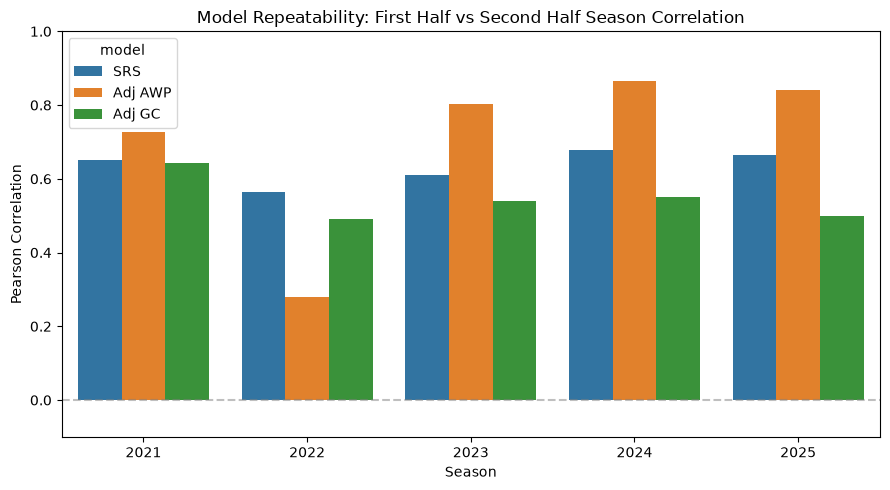

In [124]:
plt.figure(figsize=(9, 5))
sns.barplot(data=rep_all, x='season', y='correlation', hue='model', palette='tab10')
plt.axhline(0, linestyle='--', color='gray', alpha=0.5)
plt.title('Model Repeatability: First Half vs Second Half Season Correlation')
plt.xlabel('Season')
plt.ylabel('Pearson Correlation')
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()

## Part 4
### For the adjusted game control model and adjusted awp model, determine the correlation between the unadjusted values and the adjusted values for each. Calcualte the correlation by season and for all seasons combined

In [ ]:
# raw GC per team per season
raw_gc = gc_by_game.copy()
raw_gc['team_home'] = raw_gc['home_team']
raw_gc['team_away'] = raw_gc['away_team']

home_gc = raw_gc[['season','home_team','home_gc']].rename(columns={'home_team':'team','home_gc':'raw_gc'})
away_gc = raw_gc[['season','away_team','home_gc']].rename(columns={'away_team':'team','home_gc':'raw_gc'})
away_gc['raw_gc'] = -away_gc['raw_gc']

raw_gc_team = pd.concat([home_gc, away_gc]).groupby(['season','team'])['raw_gc'].mean().reset_index()

# raw AWP per team per season (home games only since wp_df is home-perspective)
raw_awp_team = wp_df.groupby(['season','home_team'])['home_wp'].mean().reset_index()
raw_awp_team.columns = ['season','team','raw_AWP']

# merge with adjusted
corr_gc  = raw_gc_team.merge(adj_gc, on=['season','team'], how='inner')
corr_awp = raw_awp_team.merge(adj_awp, on=['season','team'], how='inner')

# correlations by season
print("Adj GC vs Raw GC")
for yr, grp in corr_gc.groupby('season'):
    r, _ = pearsonr(grp['raw_gc'], grp['Adj_GC'])
    print(f"  {yr}: r = {r:.3f}")
r_all, _ = pearsonr(corr_gc['raw_gc'], corr_gc['Adj_GC'])
print(f"  All seasons combined: r = {r_all:.3f}")

print("\nAdj AWP vs Raw AWP")
for yr, grp in corr_awp.groupby('season'):
    r, _ = pearsonr(grp['raw_AWP'], grp['Adj_AWP'])
    print(f"  {yr}: r = {r:.3f}")
r_all, _ = pearsonr(corr_awp['raw_AWP'], corr_awp['Adj_AWP'])
print(f"  All seasons combined: r = {r_all:.3f}")

=== Adj GC vs Raw GC ===
  2021: r = 0.904
  2022: r = 0.932
  2023: r = 0.933
  2024: r = 0.928
  2025: r = 0.928
  All seasons combined: r = 0.925

=== Adj AWP vs Raw AWP ===
  2021: r = 0.834
  2022: r = 0.710
  2023: r = 0.669
  2024: r = 0.781
  2025: r = 0.780
  All seasons combined: r = 0.724


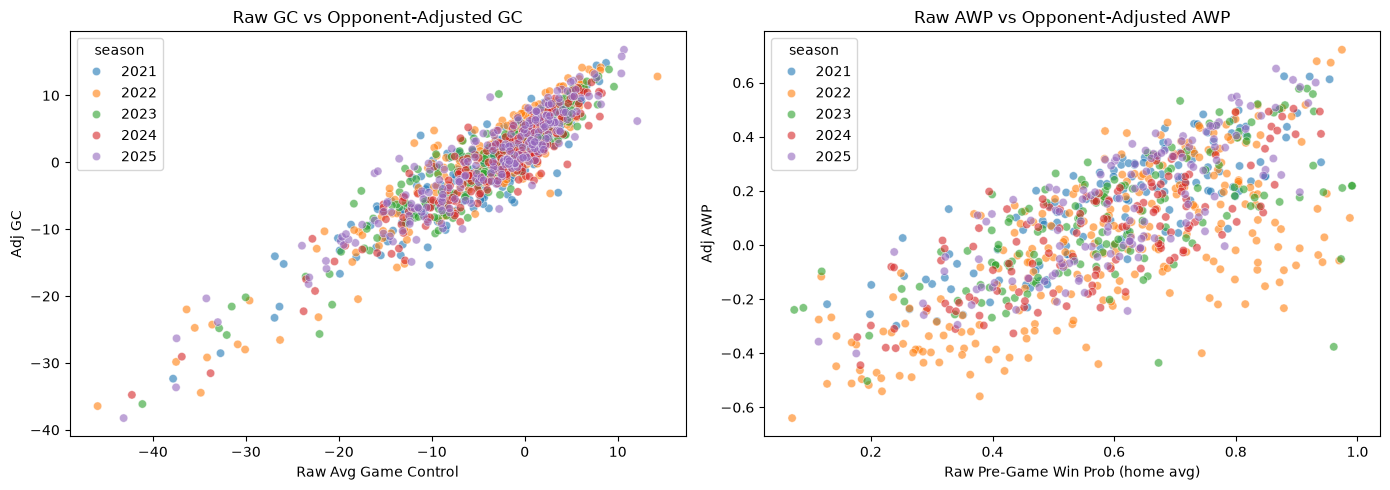

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=corr_gc, x='raw_gc', y='Adj_GC', hue='season', palette='tab10', ax=axes[0], alpha=0.6)
axes[0].set_title('Raw GC vs Opponent-Adjusted GC')
axes[0].set_xlabel('Raw Avg Game Control')
axes[0].set_ylabel('Adj GC')

sns.scatterplot(data=corr_awp, x='raw_AWP', y='Adj_AWP', hue='season', palette='tab10', ax=axes[1], alpha=0.6)
axes[1].set_title('Raw AWP vs Opponent-Adjusted AWP')
axes[1].set_xlabel('Raw Pre-Game Win Prob (home avg)')
axes[1].set_ylabel('Adj AWP')

plt.tight_layout()
plt.show()

In [ ]:
load_dotenv()
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")
db = create_client(SUPABASE_URL, SUPABASE_KEY)

# team ratings
upload = all_ratings[all_ratings['team'] != '(Intercept)'].copy()
upload = upload.rename(columns={'SRS': 'srs_rating', 'Adj_AWP': 'awp_adj', 'Adj_GC': 'gc_adj'})
upload['season'] = upload['season'].astype(int)

records = upload[['season', 'team', 'srs_rating', 'awp_adj', 'gc_adj']].to_dict(orient='records')
for i in range(0, len(records), 500):
    db.table("team_ratings").insert(records[i:i+500]).execute()
print(f"Uploaded {len(records)} team rating rows")

# model performance
# per season rows
perf_records = perf_all.copy()
perf_records['season'] = perf_records['season'].astype(str)

# merge repeatability in
rep_merged = rep_all.copy()
rep_merged['season'] = rep_merged['season'].astype(str)
perf_records = perf_records.merge(rep_merged, on=['season', 'model'], how='left')
perf_records = perf_records.rename(columns={'correlation': 'repeatability_r'})

# add all-seasons-combined row
combined = perf_records.groupby('model').agg(
    brier=('brier', 'mean'),
    log_loss=('log_loss', 'mean'),
    repeatability_r=('repeatability_r', 'mean')
).reset_index()
combined['season'] = 'all'
perf_records = pd.concat([perf_records, combined], ignore_index=True)

perf_upload = perf_records[['season', 'model', 'brier', 'log_loss', 'repeatability_r']].to_dict(orient='records')
db.table("model_performance").insert(perf_upload).execute()
print(f"Uploaded {len(perf_upload)} performance rows")

# awp and gc correlations
corr_rows = []

# gc by season
for yr, grp in corr_gc.groupby('season'):
    r, _ = pearsonr(grp['raw_gc'], grp['Adj_GC'])
    corr_rows.append({'season': str(yr), 'model': 'Adj GC', 'raw_adj_correlation': round(r, 4)})
r_all, _ = pearsonr(corr_gc['raw_gc'], corr_gc['Adj_GC'])
corr_rows.append({'season': 'all', 'model': 'Adj GC', 'raw_adj_correlation': round(r_all, 4)})

# awp by season
for yr, grp in corr_awp.groupby('season'):
    r, _ = pearsonr(grp['raw_AWP'], grp['Adj_AWP'])
    corr_rows.append({'season': str(yr), 'model': 'Adj AWP', 'raw_adj_correlation': round(r, 4)})
r_all, _ = pearsonr(corr_awp['raw_AWP'], corr_awp['Adj_AWP'])
corr_rows.append({'season': 'all', 'model': 'Adj AWP', 'raw_adj_correlation': round(r_all, 4)})

db.table("awp_gc_correlations").insert(corr_rows).execute()
print(f"Uploaded {len(corr_rows)} correlation rows")

Uploaded 662 team rating rows
Uploaded 18 performance rows
Uploaded 12 correlation rows
